Loading and preparing data...
Dataset shape after cleaning: (1146111, 31)

Performing feature engineering...

Factorizing 'TRANSPORT' column...
Transport categories: ['BUS', 'MINIBUS', 'MTR', 'BUS->BUS', 'MINIBUS->BUS', 'MTR->MINIBUS', 'MTR->BUS', 'BUS->MINIBUS', 'MINIBUS->MTR', 'BUS->MTR']
Final feature matrix shape: (1146111, 22)

Splitting data into train/test sets...


C:\Users\kelvin wong\AppData\Local\Temp\ipykernel_13148\40067221.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['TRANSPORT'], transport_categories = pd.factorize(X['TRANSPORT'])


Train size: 916888, Test size: 229223

Setting up Random Forest model...

Training baseline Random Forest model...

Evaluating model performance...

Train Set Performance:
MSE: 9.1523
RMSE: 3.0253
MAE: 1.8708
R²: 0.8943

Test Set Performance:
MSE: 11.3223
RMSE: 3.3649
MAE: 2.0768
R²: 0.8694

Analyzing feature importance...

Top 10 Most Important Features:
                              Feature  Importance
0                           TRANSPORT    0.238479
1                            DISTANCE    0.232446
2                        PASS HARBOUR    0.146977
3                            NO_STOPS    0.067140
4  NEXT ESTIMATED EMPLOYED POPULATION    0.033293
5       ESTIMATED EMPLOYED POPULATION    0.032888
6                   LIVING POPULATION    0.023584
7              NEXT LIVING POPULATION    0.023303
8                NEXT BUILDING NUMBER    0.021597
9                 NEXT DENSITY_UNIQUE    0.020492


C:\Users\kelvin wong\AppData\Local\Temp\ipykernel_13148\40067221.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


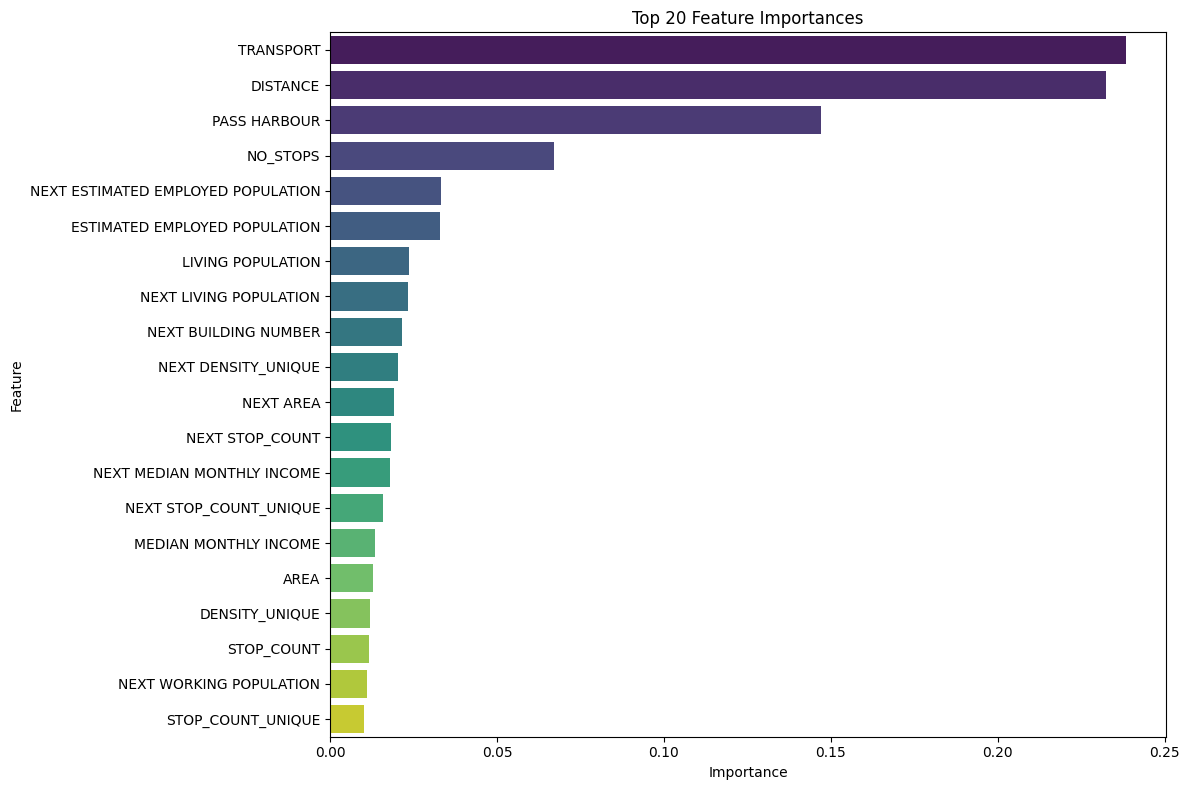

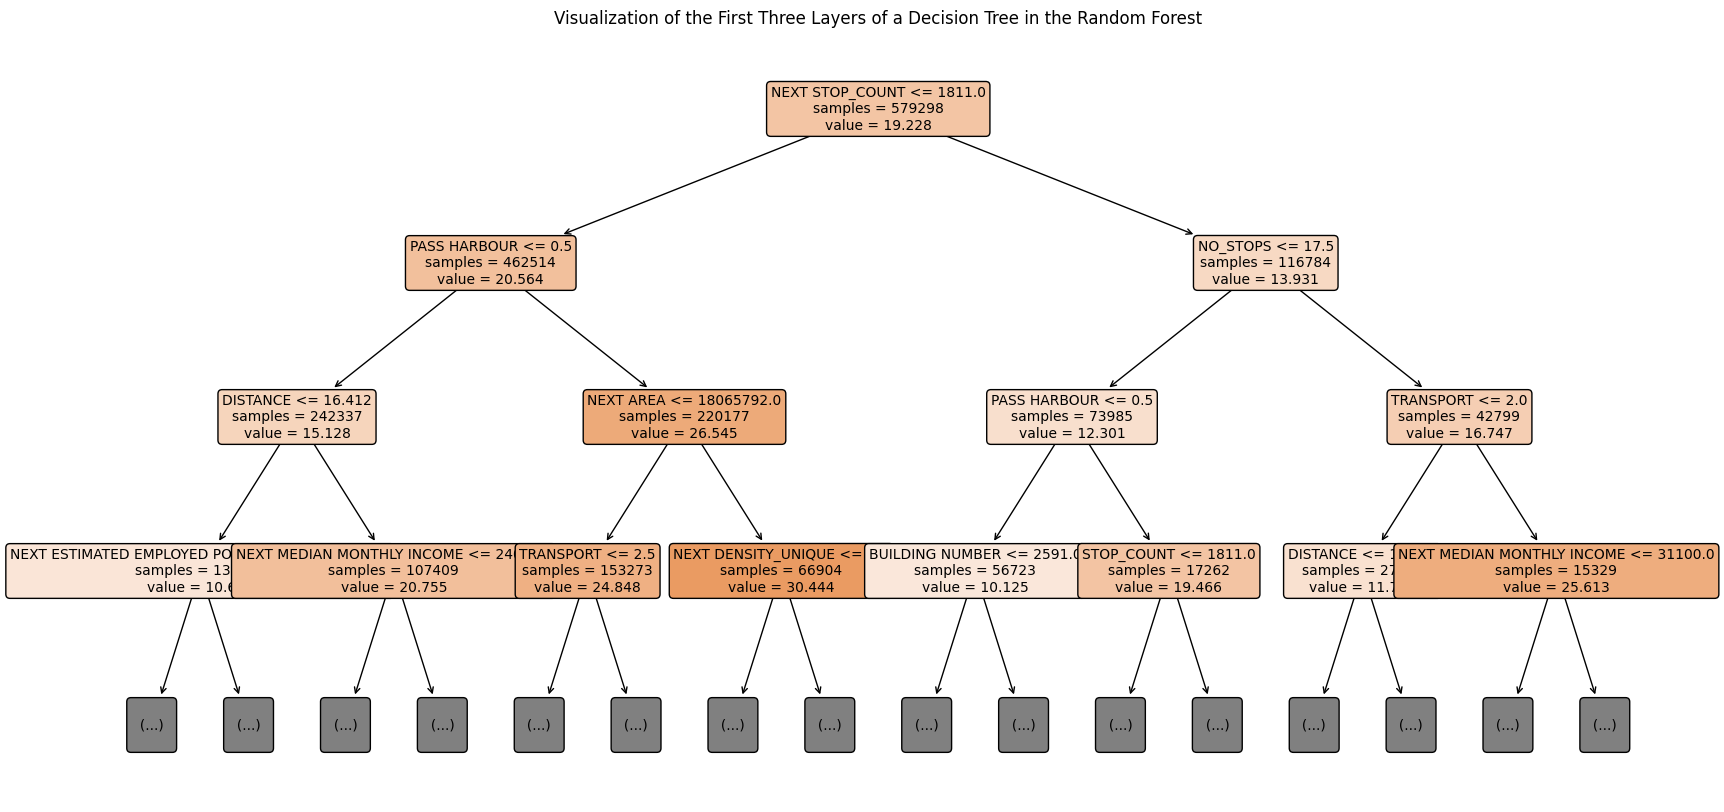

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Prepare Data
print("Loading and preparing data...")
data = pd.read_csv('final_transport_data.csv')

# Define variables
response_var = 'PRICE'
explanatory_vars = [
    # 'DISTRICT',
    # 'NEXT DISTRICT',
    'TRANSPORT',
    'NO_STOPS', 
    'DISTANCE', 
    'STOP_COUNT', 
    'STOP_COUNT_UNIQUE', 
    'AREA', 
    'DENSITY_UNIQUE', 
    'LIVING POPULATION', 
    'WORKING POPULATION', 
    'BUILDING NUMBER', 
    'ESTIMATED EMPLOYED POPULATION', 
    'MEDIAN MONTHLY INCOME', 
    'NEXT STOP_COUNT', 
    'NEXT STOP_COUNT_UNIQUE', 
    'NEXT AREA', 
    'NEXT DENSITY_UNIQUE', 
    'NEXT LIVING POPULATION', 
    'NEXT WORKING POPULATION', 
    'NEXT BUILDING NUMBER', 
    'NEXT ESTIMATED EMPLOYED POPULATION', 
    'NEXT MEDIAN MONTHLY INCOME', 
    'PASS HARBOUR'
]

# Clean data
data = data.dropna(axis=0)
print(f"Dataset shape after cleaning: {data.shape}")

# 2. Feature Engineering
print("\nPerforming feature engineering...")
X = data[explanatory_vars]
y = data[response_var]

# Factorize the 'TRANSPORT' column
if 'TRANSPORT' in X.columns:
    print("\nFactorizing 'TRANSPORT' column...")
    X['TRANSPORT'], transport_categories = pd.factorize(X['TRANSPORT'])
    print(f"Transport categories: {list(transport_categories)}")

# Convert other categorical variables (if any) to dummy variables
# turn District and Next District into variables (using one hot encoding)
# X = pd.get_dummies(X, columns=['DISTRICT', 'NEXT DISTRICT'], drop_first=True)
print(f"Final feature matrix shape: {X.shape}")

# 3. Train-Test Split
print("\nSplitting data into train/test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# 4. Random Forest Model Setup
print("\nSetting up Random Forest model...")
rf = RandomForestRegressor(
    n_estimators=200,  
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=2,  
    max_features='sqrt',
    random_state=42,
    n_jobs=-1  
) 

# 5. Train Random Forest Model
print("\nTraining baseline Random Forest model...")
rf.fit(X_train, y_train)

# 6. Model Evaluation
print("\nEvaluating model performance...")
y_pred_train = rf.predict(X_train)
y_pred = rf.predict(X_test)

# Calculate performance metrics
train_metrics = {
    'MSE': mean_squared_error(y_train, y_pred_train),
    'RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
    'MAE': mean_absolute_error(y_train, y_pred_train),
    'R²': r2_score(y_train, y_pred_train)
}
print("\nTrain Set Performance:")
for name, value in train_metrics.items():
    print(f"{name}: {value:.4f}")

metrics = {
    'MSE': mean_squared_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    'MAE': mean_absolute_error(y_test, y_pred),
    'R²': r2_score(y_test, y_pred)
}

print("\nTest Set Performance:")
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

# 7. Feature Importance Analysis
print("\nAnalyzing feature importance...")
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns[indices],
    'Importance': importances[indices]
})

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(20),
    palette='viridis'
)
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()  # Display the image


from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot the first three layers of the first tree in the Random Forest
plt.figure(figsize=(20, 10))
plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3,  # Limit the visualization to the first three layers
    impurity=False,  # Exclude impurity (e.g., Gini or MSE)
    proportion=False  # Exclude proportions
)
plt.title("Visualization of the First Three Layers of a Decision Tree in the Random Forest")
plt.show()




In [7]:
# print the feature importance of all the features
print("\nFeature Importance of All Features:")
for i in range(len(importances)):
    print(f"{X.columns[i]}: {importances[i]:.4f}")



Feature Importance of All Features:
TRANSPORT: 0.2385
NO_STOPS: 0.0671
DISTANCE: 0.2324
STOP_COUNT: 0.0117
STOP_COUNT_UNIQUE: 0.0102
AREA: 0.0130
DENSITY_UNIQUE: 0.0121
LIVING POPULATION: 0.0236
WORKING POPULATION: 0.0081
BUILDING NUMBER: 0.0088
ESTIMATED EMPLOYED POPULATION: 0.0329
MEDIAN MONTHLY INCOME: 0.0135
NEXT STOP_COUNT: 0.0182
NEXT STOP_COUNT_UNIQUE: 0.0159
NEXT AREA: 0.0192
NEXT DENSITY_UNIQUE: 0.0205
NEXT LIVING POPULATION: 0.0233
NEXT WORKING POPULATION: 0.0111
NEXT BUILDING NUMBER: 0.0216
NEXT ESTIMATED EMPLOYED POPULATION: 0.0333
NEXT MEDIAN MONTHLY INCOME: 0.0181
PASS HARBOUR: 0.1470


In [8]:
test_results = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'DISTRICT': data.loc[X_test.index, 'DISTRICT'],  
    'NEXT DISTRICT': data.loc[X_test.index, 'NEXT DISTRICT']  
})

grouped_mse = test_results.groupby(['DISTRICT', 'NEXT DISTRICT']).apply(
    lambda group: mean_squared_error(group['y_true'], group['y_pred'])
).reset_index(name='MSE')

# Sort by MSE 
grouped_mse = grouped_mse.sort_values(by='MSE', ascending=False)  

# Print results
print("\nMSE by (DISTRICT, NEXT DISTRICT) groups:")
print(grouped_mse)

# Calculate trimmed mean of MSE
from scipy.stats import trim_mean  

mse_values = grouped_mse['MSE'].values

trimmed_mean_mse = trim_mean(mse_values, proportiontocut=0.05)

print(f"\nTrimmed Mean MSE (5%): {trimmed_mean_mse:.4f}")



MSE by (DISTRICT, NEXT DISTRICT) groups:
                         DISTRICT                NEXT DISTRICT         MSE
475                  Robin's Nest                 Sha Tin West  304.413247
643                  Sha Tin West                 Robin's Nest  278.442037
528                  Sha Tin East                 Robin's Nest  263.724947
474                  Robin's Nest                Sha Tin South  220.031542
473                  Robin's Nest                Sha Tin North  183.173724
...                           ...                          ...         ...
446                Kwun Tong West  Southern District Southeast    0.000283
1567         Yuen Long Rural East                     Hong Wan    0.000214
1334                      Western              Kwai Chung East    0.000094
1332                      Western           Kowloon City North    0.000084
768   Southern District Northwest               Kwun Tong West    0.000059

[1637 rows x 3 columns]

Trimmed Mean MSE (5%): 7.8666


C:\Users\kelvin wong\AppData\Local\Temp\ipykernel_13148\4006851332.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_mse = test_results.groupby(['DISTRICT', 'NEXT DISTRICT']).apply(


In [9]:
# 1. Filter groups where MSE > trimmed mean
high_mse_groups = grouped_mse[grouped_mse['MSE'] > trimmed_mean_mse].copy()

# 2. Convert to a list of dictionaries (one per group)
high_mse_list = high_mse_groups.to_dict('records')

# 3. Print first 5 as example
for group in high_mse_list[:5]:  
    print(f"{group['DISTRICT']} → {group['NEXT DISTRICT']}: MSE = {group['MSE']:.2f}")

# 4. print the number of pairs
print(f"Number of pairs exceeding trimmed mean of MSE: {len(high_mse_groups)}")


Robin's Nest → Sha Tin West: MSE = 304.41
Sha Tin West → Robin's Nest: MSE = 278.44
Sha Tin East → Robin's Nest: MSE = 263.72
Robin's Nest → Sha Tin South: MSE = 220.03
Robin's Nest → Sha Tin North: MSE = 183.17
Number of pairs exceeding trimmed mean of MSE: 582


In [10]:
# 1. Calculate relative deviation
test_results['relative_deviation'] = abs(test_results['y_true'] - test_results['y_pred']) / test_results['y_true']

# 2. Group by (DISTRICT, NEXT DISTRICT) and compute mean relative deviation
grouped_deviation = test_results.groupby(['DISTRICT', 'NEXT DISTRICT']).agg(
    mean_relative_deviation=('relative_deviation', 'mean'), 
    n_samples=('relative_deviation', 'count'),              
    y_true_mean=('y_true', 'mean')                          
).reset_index()

# 3. Set threshold using trimmed mean 
relative_threshold = trim_mean(
    grouped_deviation['mean_relative_deviation'], 
    proportiontocut=0.05  
)
print(f"Relative Deviation Threshold: {relative_threshold:.2%}")

# 4. Filter groups where relative deviation exceeds the threshold
unreasonble_groups = grouped_deviation[
    grouped_deviation['mean_relative_deviation'] > relative_threshold
].copy()

# (Optional) Add a minimum sample size filter
unreasonble_groups = unreasonble_groups[unreasonble_groups['n_samples'] > 5]  

# 5. Sort by worst-performing pairs (highest % error first)
unreasonble_groups = unreasonble_groups.sort_values(
    by='mean_relative_deviation', 
    ascending=False
)
# Save the unreasonable groups to a CSV file
unreasonble_groups.to_csv('unreasonableset.csv', index=False)

print("Results have been saved to unreasonableset.csv")

# 6. Print results
print(f"\nNumber of unreasonable pairs: {len(unreasonble_groups)}")
print("\nTop 10 % error pairs:")
for _, row in unreasonble_groups.head(10).iterrows():
    print(
        f"{row['DISTRICT']} → {row['NEXT DISTRICT']}: "
        f"Error: {row['mean_relative_deviation']:.1%} "
        f"(Avg price: ${row['y_true_mean']:.2f}, Samples: {row['n_samples']})"
    )

Relative Deviation Threshold: 12.86%
Results have been saved to unreasonableset.csv

Number of unreasonable pairs: 642

Top 10 % error pairs:
Tuen Mun North → Yau Tsim Mong South: Error: 121.5% (Avg price: $18.47, Samples: 44)
Islands → Kwai Chung West: Error: 113.8% (Avg price: $13.49, Samples: 37)
Tseung Kwan O North → Kwai Chung East: Error: 110.6% (Avg price: $7.70, Samples: 8)
Sai Kung and Hang Hau → Tsuen Wan Northwest: Error: 91.2% (Avg price: $15.92, Samples: 11)
Tin Shui Wai South and Ping Ha → Kwun Tong West: Error: 84.3% (Avg price: $15.03, Samples: 33)
Tseung Kwan O North → Kwai Chung West: Error: 81.0% (Avg price: $9.74, Samples: 25)
Tin Shui Wai South and Ping Ha → Wong Tai Sin East: Error: 80.0% (Avg price: $15.27, Samples: 38)
Sai Kung and Hang Hau → Kwai Chung East: Error: 74.3% (Avg price: $15.35, Samples: 21)
Yuen Long Town Centre → Kwun Tong Central: Error: 73.5% (Avg price: $16.51, Samples: 31)
Tuen Mun North → Tuen Mun East: Error: 71.6% (Avg price: $16.51, Sample

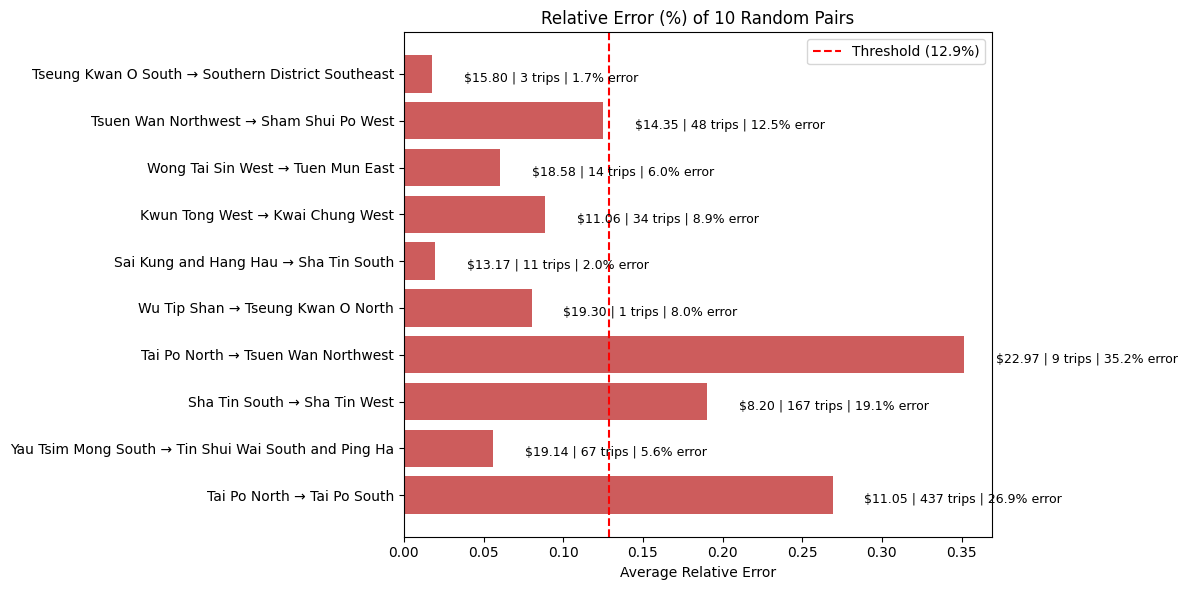

In [11]:
# randomly select 10 pairs
top10 = grouped_deviation.sample(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(
    y=top10['DISTRICT'] + ' → ' + top10['NEXT DISTRICT'],
    width=top10['mean_relative_deviation'],
    color='indianred'
)

# Add error labels, price info, and relative error percentage
for i, bar in enumerate(bars):
    price = top10.iloc[i]['y_true_mean']
    error_pct = top10.iloc[i]['mean_relative_deviation']
    
    # Label on the right side of bars
    plt.text(bar.get_width()+0.02, bar.get_y()+0.3,
             f"${price:.2f} | {top10.iloc[i]['n_samples']} trips | {error_pct:.1%} error",
             fontsize=9,
             va='center')

plt.axvline(relative_threshold, color='r', linestyle='--', label=f'Threshold ({relative_threshold:.1%})')
plt.title('Relative Error (%) of 10 Random Pairs')
plt.xlabel('Average Relative Error')
plt.legend()
plt.tight_layout()
plt.show()


Constituency with Most High Relative Error Routes:
                          DISTRICT  high_deviation_pairs  avg_error  avg_price
0              Tsuen Wan Northwest                    25   0.222544  18.539801
2              Yau Tsim Mong South                    23   0.242786  13.814290
3              Yau Tsim Mong North                    23   0.242489  11.939488
1            Sai Kung and Hang Hau                    23   0.362716  12.725750
4                   Tuen Mun North                    22   0.363896  14.694594
5   Tin Shui Wai South and Ping Ha                    22   0.424365  13.733288
6                    Tuen Mun West                    21   0.256428  17.488236
7               Kowloon City North                    21   0.204361  11.229465
8                Sham Shui Po East                    20   0.192899   9.804426
11                 Kwun Tong North                    19   0.224189  11.166180
12               Wong Tai Sin East                    19   0.244722   9.748956


C:\Users\kelvin wong\AppData\Local\Temp\ipykernel_13148\4248825659.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


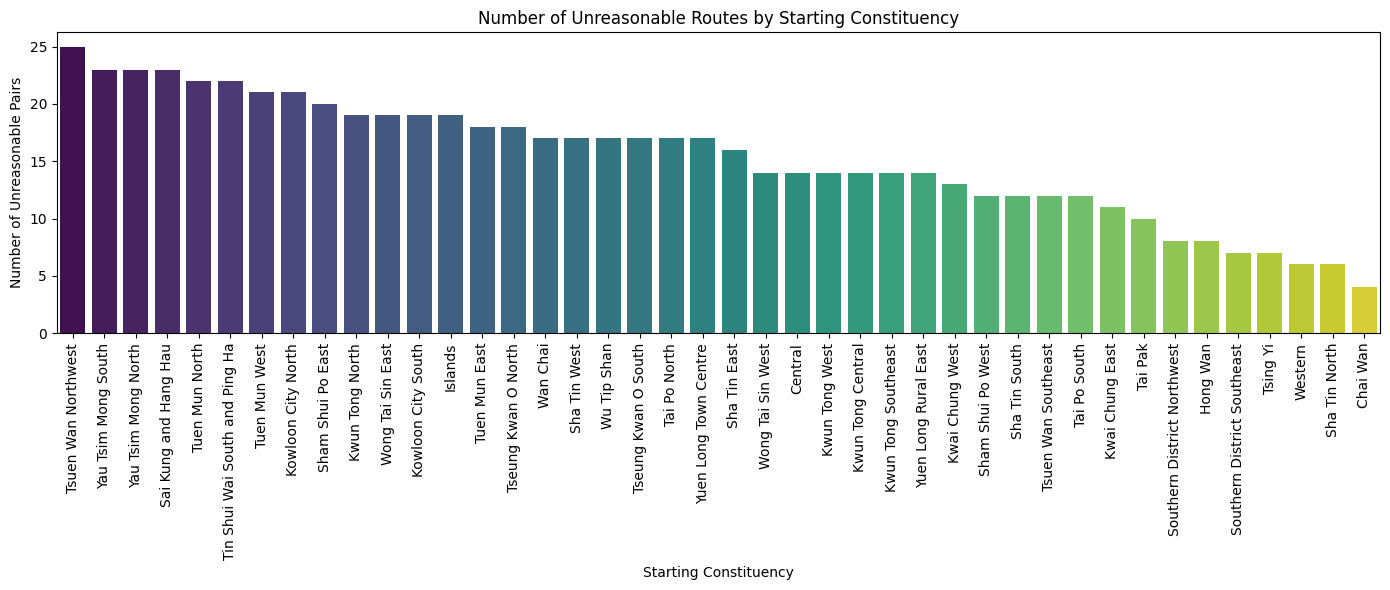

In [12]:
# Group by starting DISTRICT and count high-deviation pairs
district_analysis = unreasonble_groups.groupby('DISTRICT').agg(
    high_deviation_pairs=('NEXT DISTRICT', 'count'),
    avg_error=('mean_relative_deviation', 'mean'),
    avg_price=('y_true_mean', 'mean')
).sort_values('high_deviation_pairs', ascending=False).reset_index()

print("\nConstituency with Most High Relative Error Routes:")
print(district_analysis.sort_values('high_deviation_pairs', ascending=False))

plt.figure(figsize=(14, 6))
sns.barplot(
    data=district_analysis, 
    x='DISTRICT', 
    y='high_deviation_pairs',
    order=district_analysis.sort_values('high_deviation_pairs', ascending=False)['DISTRICT'],
    palette='viridis'
)
plt.xticks(rotation=90)
plt.title('Number of Unreasonable Routes by Starting Constituency')
plt.xlabel('Starting Constituency')
plt.ylabel('Number of Unreasonable Pairs')
plt.tight_layout()
plt.show()